#  IA para Redes de Suministro 

👤 **Autor:** John Leonardo Vargas Mesa  
🔗 [LinkedIn](https://www.linkedin.com/in/leonardovargas/) | [GitHub](https://github.com/LeStark)  

## 📂 Repositorio en GitHub  
- 📓 **Notebooks:** [Acceder aquí](https://github.com/LeStark/Cursos/tree/main/02%20-%20IA4SC)  
- 📑 **Data sets:** [Acceder aquí](https://github.com/LeStark/Cursos/tree/main/00%20-%20Data/02%20-%20SC)  
---

In [16]:
# --- Librerías principales de análisis y visualización ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

#  Descripción de los conjuntos de datos de demanda y pedidos

Estos dos conjuntos de datos representan la información básica utilizada para analizar el comportamiento del inventario de un producto específico (en este caso, el producto **1001**) a lo largo del tiempo.  
Su propósito es alimentar los modelos de simulación y optimización de políticas de inventario (como EOQ o ROP) mediante datos de **demanda real** y **tiempos de reposición (lead time)**.

## 1️ Dataset de Demanda (`Data_demanda`)

| Columna | Descripción |
|----------|--------------|
| **Fecha** | Día calendario en el que se registró la demanda. |
| **Producto** | Código único del producto. En este ejemplo, solo se analiza el producto `1001`. |
| **Demanda** | Número de unidades demandadas (o vendidas) en esa fecha. |


###  Uso
Este dataset permite:
- Calcular la **media y desviación estándar** de la demanda.
- Analizar patrones diarios o semanales.
- Simular la reducción del inventario día a día según la demanda.
- Estimar la **demanda esperada durante el lead time**, clave para determinar el punto de reorden (ROP).

##  2️ Dataset de Pedidos (`Data_pedidos`)

| Columna | Descripción |
|----------|--------------|
| **Producto** | Código del producto pedido. |
| **Fecha Pedido** | Fecha en la que se realizó el pedido al proveedor. |
| **Fecha Recepción** | Fecha en la que el pedido fue recibido y agregado al inventario. |
| **Cantidad** | Número de unidades pedidas. |

### 💡 Uso
Este dataset se utiliza para:
- Calcular el **Lead Time (días)** = `Fecha Recepción - Fecha Pedido`.
- Obtener la **media y variabilidad** del tiempo de reposición.
- Analizar la frecuencia de pedidos y los volúmenes de reabastecimiento.
- Integrar con la demanda para simular políticas de inventario y evaluar costos de:
  - Mantenimiento (holding cost),
  - Pedido (ordering cost),
  - Ruptura de stock (stockout cost).

##  Relación entre ambos datasets

- `Data_demanda` refleja **la salida** del inventario (consumo o ventas).  
- `Data_pedidos` refleja **la entrada** del inventario (reposición de stock).  
- La combinación de ambos permite modelar la dinámica completa del sistema de inventario y calcular indicadores como:
  - Nivel promedio de inventario,
  - Frecuencia de quiebres de stock,
  - Costos totales del sistema bajo diferentes políticas de \( Q \) y \( ROP \).


In [17]:
url_demanda = "https://raw.githubusercontent.com/LeStark/Cursos/refs/heads/main/00%20-%20Data/02%20-%20SC/Optimizacion%20Inventarios/Data_demanda.csv"
url_pedidos = "https://raw.githubusercontent.com/LeStark/Cursos/refs/heads/main/00%20-%20Data/02%20-%20SC/Optimizacion%20Inventarios/Data_pedidos.csv"

Data_demanda = pd.read_csv(url_demanda)
Data_pedidos = pd.read_csv(url_pedidos)

In [18]:
# --- Conversión de columnas a tipo datetime ---
Data_pedidos["Fecha Pedido"] = pd.to_datetime(Data_pedidos["Fecha Pedido"], errors="coerce")
Data_pedidos["Fecha Recepción"] = pd.to_datetime(Data_pedidos["Fecha Recepción"], errors="coerce")
Data_demanda["Fecha"] = pd.to_datetime(Data_demanda["Fecha"], errors="coerce")
# --- Verificación ---
print(Data_pedidos.dtypes)
print(Data_pedidos.head())

Producto                    int64
Fecha Pedido       datetime64[ns]
Fecha Recepción    datetime64[ns]
Cantidad                    int64
dtype: object
   Producto Fecha Pedido Fecha Recepción  Cantidad
0      1001   2024-02-12      2024-02-15       318
1      1001   2024-04-20      2024-04-25       474
2      1001   2024-04-24      2024-04-27       362
3      1001   2024-05-25      2024-05-30       439
4      1001   2024-05-28      2024-06-01       392


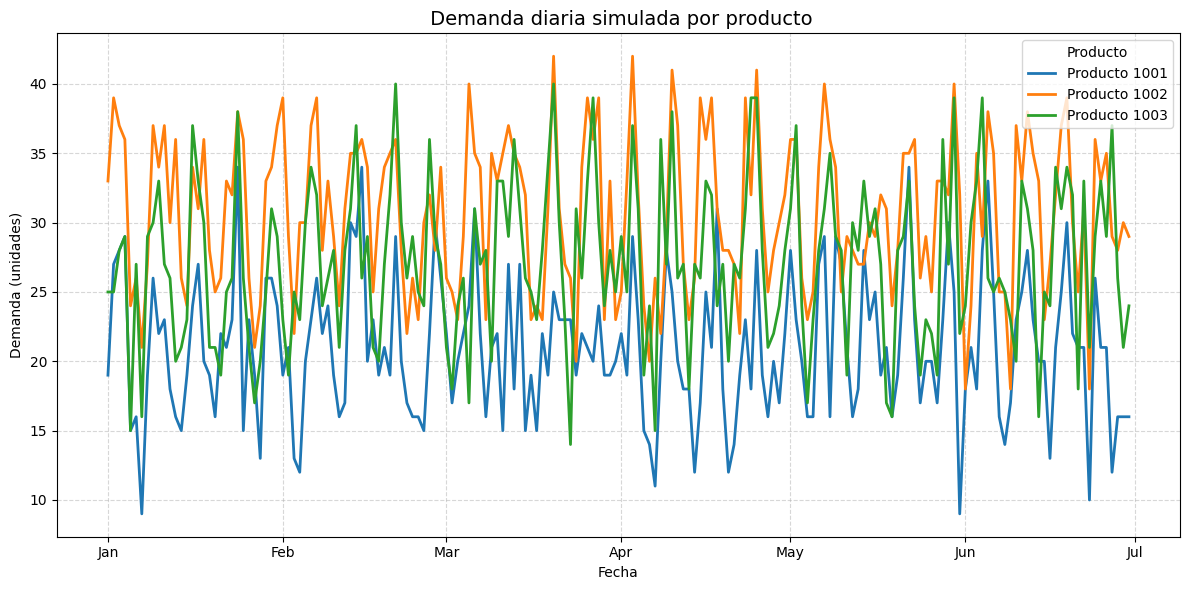

In [19]:
# --- Asegurarnos de que las fechas estén ordenadas ---
Data_demanda = Data_demanda.sort_values(["Producto", "Fecha"])

# --- Crear la figura ---
plt.figure(figsize=(12,6))

# --- Graficar demanda diaria para cada producto ---
for pid in Data_demanda["Producto"].unique():
    df_prod = Data_demanda[Data_demanda["Producto"] == pid]
    plt.plot(
        df_prod["Fecha"],
        df_prod["Demanda"],
        linewidth=2,
        label=f"Producto {pid}"
    )

# --- Personalización ---
plt.title(" Demanda diaria simulada por producto", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Demanda (unidades)")
plt.legend(title="Producto", loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

# Mostrar solo los meses en el eje X
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.show()



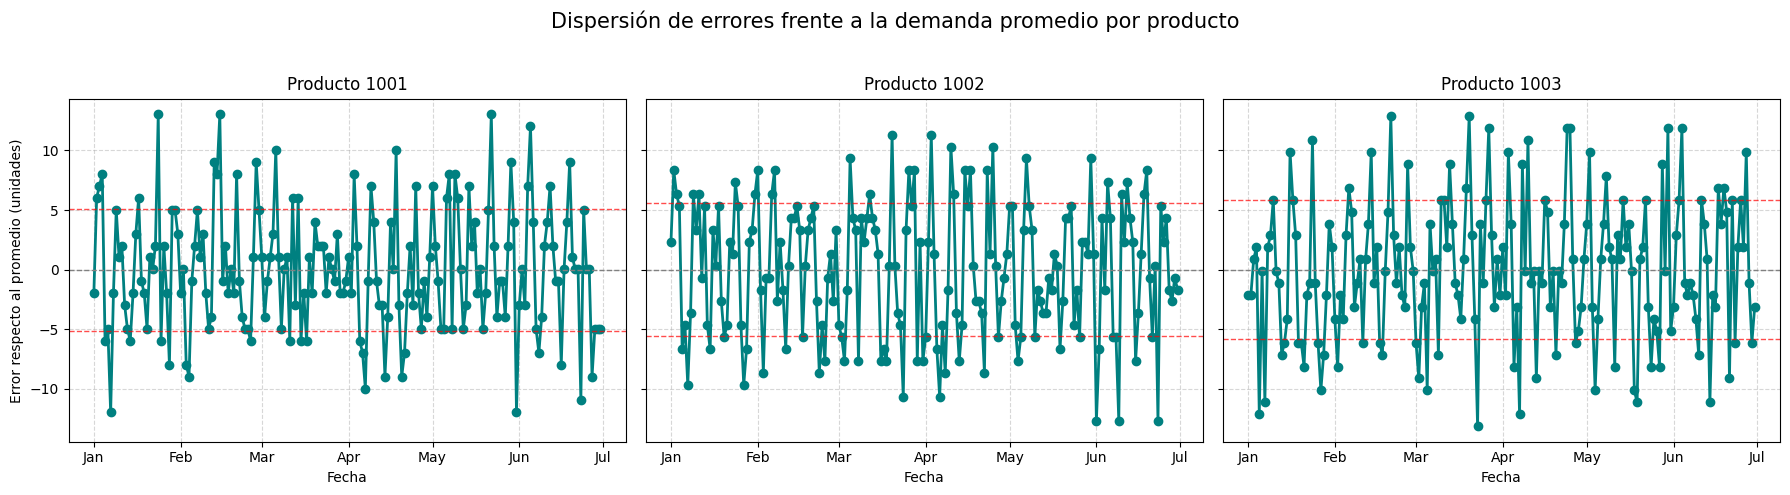

In [20]:
# --- Asegurar que las fechas estén ordenadas ---
Data_demanda = Data_demanda.sort_values(["Producto", "Fecha"])

# --- Calcular demanda promedio por producto ---
promedios = Data_demanda.groupby("Producto")["Demanda"].mean().to_dict()

# --- Calcular el error respecto al promedio ---
Data_demanda["Error"] = Data_demanda.apply(
    lambda row: row["Demanda"] - promedios[row["Producto"]],
    axis=1
)

# --- Crear figura con subplots (1 fila x 3 columnas) ---
productos = Data_demanda["Producto"].unique()
fig, axes = plt.subplots(1, len(productos), figsize=(18, 5), sharey=True)

for i, pid in enumerate(productos):
    df_prod = Data_demanda[Data_demanda["Producto"] == pid]
    ax = axes[i]

    # --- Línea de error ---
    ax.plot(df_prod["Fecha"], df_prod["Error"], marker="o", linewidth=2, label=f"Producto {pid}", color="teal")

    # --- Líneas de referencia ---
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.axhline(df_prod["Error"].std(), color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(-df_prod["Error"].std(), color="red", linestyle="--", linewidth=1, alpha=0.7)

    # --- Personalización de cada subplot ---
    ax.set_title(f"Producto {pid}", fontsize=12)
    ax.set_xlabel("Fecha")
    if i == 0:
        ax.set_ylabel("Error respecto al promedio (unidades)")
    ax.grid(True, linestyle="--", alpha=0.5)

    # Mostrar solo meses en el eje X
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- Ajuste general ---
fig.suptitle("Dispersión de errores frente a la demanda promedio por producto", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()




#  Análisis estadístico de la demanda y el lead time

En este bloque se realiza el análisis descriptivo de las variables clave del sistema de inventario, con el propósito de comprender su comportamiento antes de aplicar modelos de optimización o simulación.

## 🔹 1️ Medias y desviaciones de la DEMANDA por producto
Se agrupan los registros de la base de datos `Data_demanda` por producto y se calculan los indicadores básicos:
- **Media_Demanda:** promedio de las unidades demandadas por día.
- **Desv_Demanda:** desviación estándar, que mide la variabilidad de la demanda.
- **Max_Demanda / Min_Demanda:** valores extremos observados.

Esto permite identificar productos con mayor volatilidad en la demanda, lo cual impacta directamente en el punto de reorden y el tamaño de pedido óptimo.

## 🔹 2️ Cálculo del LEAD TIME
A partir de la tabla `Data_pedidos`, se calcula el **Lead Time en días** como la diferencia entre la fecha de recepción y la fecha del pedido.  
Este indicador refleja el tiempo promedio que tarda el proveedor en entregar los productos.


## 🔹 3️ Medias y desviaciones del LEAD TIME por producto
De manera análoga, se agrupan los registros de `Data_pedidos` por producto y se calculan:
- **Media_LeadTime:** tiempo promedio de entrega.
- **Desv_LeadTime:** variabilidad del tiempo de entrega.
- **Máximo y mínimo Lead Time:** rangos de comportamiento del proveedor.

Con esta información se pueden determinar los **niveles de seguridad** y los **puntos de reorden (ROP)** considerando tanto la incertidumbre en la demanda como la del tiempo de reposición.


In [21]:
# --- 1️ Medias y desviaciones de la DEMANDA por producto ---
stats_demanda = (
    Data_demanda
    .groupby("Producto")["Demanda"]
    .agg(
        Media_Demanda="mean",
        Desv_Demanda="std",
        Max_Demanda="max",
        Min_Demanda="min"
    )
    .reset_index()
)

print(" Estadísticas de la demanda por producto:")
print(stats_demanda)

# --- 2️ Calcular Lead Time en días ---
Data_pedidos["Lead Time (días)"] = (
    Data_pedidos["Fecha Recepción"] - Data_pedidos["Fecha Pedido"]
).dt.days

# --- 3️ Medias y desviaciones del LEAD TIME por producto ---
stats_leadtime = (
    Data_pedidos
    .groupby("Producto")["Lead Time (días)"]
    .agg(
        Media_LeadTime="mean",
        Desv_LeadTime="std",
        Max_LeadTime="max",
        Min_LeadTime="min"
    )
    .reset_index()
)

print("\n Estadísticas del lead time por producto:")
print(stats_leadtime)

 Estadísticas de la demanda por producto:
   Producto  Media_Demanda  Desv_Demanda  Max_Demanda  Min_Demanda
0      1001      20.978022      5.110877           34            9
1      1002      30.670330      5.576301           42           18
2      1003      27.131868      5.813318           40           14

 Estadísticas del lead time por producto:
   Producto  Media_LeadTime  Desv_LeadTime  Max_LeadTime  Min_LeadTime
0      1001        3.625000       1.060660             5             2
1      1002        4.142857       1.951800             7             2
2      1003        4.714286       1.976047             7             2



## Optimización de inventarios basada en el costo total

En la gestión de inventarios, el objetivo no es solo mantener el nivel de servicio, sino **minimizar el costo total del sistema**.  
Esto implica encontrar un equilibrio entre cuatro componentes principales del costo logístico:

### 1️ Costo de compra o producción
Representa el valor de adquisición de cada unidad del producto.  
Aunque normalmente es fijo, se incluye como base para calcular los demás costos.

\[
C_{\text{unitario}} = \text{Precio de compra o costo de fabricación}
\]

### 2️ Costo de mantenimiento o posesión (Holding Cost)
Corresponde al costo de mantener una unidad en inventario durante un período.  
Incluye almacenamiento, seguros, deterioro, obsolescencia y costo financiero del capital invertido.

Se calcula como una proporción del costo unitario, llamada **tasa de mantenimiento anual (holding rate)**.  
Para convertirlo a **costo diario por unidad**, se divide entre 365 días:

\[
h_{\text{diario}} = \frac{r_h \cdot C_{\text{unitario}}}{365}
\]

donde:
- \( r_h \): tasa de mantenimiento anual (por ejemplo, 25%)
- \( C_{\text{unitario}} \): costo unitario del producto

### 3️ Costo de pedido (Ordering Cost)
Es el costo fijo asociado a realizar un pedido, sin importar la cantidad solicitada.  
Incluye actividades administrativas, transporte inicial o coordinación con el proveedor.

\[
C_{\text{pedido}} = \text{Costo fijo por orden colocada}
\]

Este valor afecta directamente la **cantidad económica de pedido (EOQ)**, ya que a mayor costo de pedido, conviene hacer menos órdenes, pero más grandes.

### 4️ Costo de ruptura de stock (Stockout Cost)
Se refiere al costo que incurre la empresa cuando **no puede satisfacer la demanda** por falta de inventario.  
Puede representar:
- Pérdida directa de ventas,  
- Penalizaciones contractuales,  
- O pérdida de confianza del cliente.

\[
C_{\text{ruptura}} = \text{Costo por unidad no servida}
\]



In [22]:
# ==========================================================
# Costos por producto
# ----------------------------------------------------------
# En este bloque se definen los componentes del costo total
# asociados a la gestión de inventario para distintos productos.
# Cada tipo de costo representa un factor económico que el
# modelo de optimización considerará al calcular la política óptima (Q, ROP).
# ==========================================================

# --- Diccionario de costos por producto ---
# Las claves (1001, 1002, 1003) son los identificadores de producto.
# Cada uno contiene cuatro parámetros fundamentales:
#   - unit_cost: costo unitario o precio de compra del producto.
#   - holding_rate: tasa de mantenimiento anual (% del costo unitario).
#   - ordering_cost: costo fijo de cada pedido (independiente de la cantidad).
#   - stockout_cost: costo por unidad no servida (ruptura de stock).
costos = {
    1001: {"unit_cost": 10.0, "holding_rate": 0.25, "ordering_cost": 22000.0,  "stockout_cost": 60.0},
    1002: {"unit_cost": 12.0, "holding_rate": 0.22, "ordering_cost": 32000.0,  "stockout_cost": 50.0},
    1003: {"unit_cost": 8.0,  "holding_rate": 0.28, "ordering_cost": 16000.0,  "stockout_cost": 70.0},
}


# ==========================================================
# Función auxiliar: costos_producto(pid)
# ----------------------------------------------------------
# Esta función recibe el identificador de producto (pid) y devuelve:
#   1️ h_diario: costo de mantenimiento diario por unidad.
#       - Se calcula multiplicando el costo unitario por la tasa anual
#         de mantenimiento y dividiendo entre 365 días.
#       - Este valor refleja cuánto cuesta mantener una unidad en inventario por día.
#
#   2️ ordering_cost: costo fijo por pedido.
#
#   3️ stockout_cost: costo por unidad no servida (demanda insatisfecha).
#
# Estos valores se usan en el simulador y en la función objetivo del
# modelo de optimización para estimar el costo total esperado del inventario.
# ==========================================================
def costos_producto(pid):
    c = costos[pid]
    h_diario = (c["holding_rate"] * c["unit_cost"]) / 365.0  # costo de posesión por unidad y día
    return h_diario, c["ordering_cost"], c["stockout_cost"]



## Simulador de inventario (modelo (Q, ROP))

Esta función implementa un **simulador discreto de inventarios** bajo una política de revisión continua tipo **(Q, ROP)**:
- **Q (Quantity)**: cantidad fija que se ordena cada vez que el inventario cae por debajo del punto de reorden.  
- **ROP (Reorder Point)**: nivel de inventario que dispara un nuevo pedido.

El objetivo del simulador es **estimar el costo total esperado** de operación para una combinación dada de \( Q \) y \( ROP \), considerando:
- Demanda diaria (dataset `Data_demanda`),
- Tiempos de reposición variables (`Data_pedidos`),
- Costos económicos: mantenimiento, pedido y ruptura (`costos_producto`).

Al ejecutarse, el simulador:
1. **Inicializa el inventario** y las variables de control.
2. Recorre día a día la demanda y actualiza los niveles de inventario.
3. **Genera pedidos** cuando el inventario cae bajo el ROP.
4. **Calcula costos acumulados** de mantenimiento, pedidos y rupturas de stock.
5. Retorna un **resumen cuantitativo** y un **histórico detallado diario**.  
   Opcionalmente, genera una **gráfica** con la evolución del inventario, los pedidos y los días con ruptura.

Este simulador actúa como la **función de evaluación** dentro de los algoritmos de optimización (por ejemplo, PSO, GA, o búsqueda local), donde el costo total es la métrica a minimizar.


In [23]:

def simulador_inventario(
    producto_id: int,
    Data_demanda: pd.DataFrame,
    Data_pedidos: pd.DataFrame,
    Q: int,
    ROP: int,
    h: float = None,              # costo de mantenimiento diario por unidad
    S: float = None,              # costo de pedido
    p: float = None,              # costo de ruptura
    graficar: bool = True         # muestra gráfico si es True
):
    """
    Simula el comportamiento diario de un sistema de inventario bajo una política (Q, ROP)
    y calcula los costos totales asociados.

    Parámetros:
    -----------
    producto_id : int
        Identificador del producto.
    Data_demanda : DataFrame
        Contiene la demanda diaria por producto (columnas: Fecha, Producto, Demanda).
    Data_pedidos : DataFrame
        Contiene las fechas de pedido y recepción para estimar los lead times.
    Q : int
        Cantidad de pedido fija.
    ROP : int
        Punto de reorden (nivel de inventario que activa un pedido).
    h : float, opcional
        Costo de mantenimiento diario por unidad. Si es None, se toma de `costos_producto`.
    S : float, opcional
        Costo fijo de pedido. Si es None, se toma de `costos_producto`.
    p : float, opcional
        Costo por unidad en ruptura de stock. Si es None, se toma de `costos_producto`.
    graficar : bool, opcional
        Si True, muestra la evolución del inventario en el tiempo.

    Retorna:
    --------
    resumen : dict
        Contiene métricas agregadas de desempeño y costos totales.
    df_hist : DataFrame
        Registro diario detallado de inventario, ventas, pérdidas y costos acumulados.
    """

    # --- Costos del producto ---
    # Si no se especifican, se obtienen desde la función costos_producto()
    if h is None or S is None or p is None:
        h, S, p = costos_producto(producto_id)

    # --- Selección y preparación de datos de demanda y lead time ---
    df_demanda = Data_demanda[Data_demanda["Producto"] == producto_id].sort_values("Fecha").copy()
    lead_times = (
        Data_pedidos[Data_pedidos["Producto"] == producto_id]["Fecha Recepción"]
        - Data_pedidos[Data_pedidos["Producto"] == producto_id]["Fecha Pedido"]
    ).dt.days.values

    if len(lead_times) == 0:
        raise ValueError(f"No hay datos de lead time para el producto {producto_id}")

    # --- Inicialización de variables del simulador ---
    dias = len(df_demanda)
    on_hand = ROP + Q // 2         # inventario inicial
    on_order = []                  # lista de pedidos pendientes (día de llegada, cantidad)

    # Variables acumulativas de costos y eventos
    cost_holding = 0.0
    cost_order   = 0.0
    cost_stock   = 0.0
    pedidos = 0
    stockout_dias = 0
    hist = []  # registro diario

    # ==============================================================
    #  Bucle principal: simulación día a día
    # ==============================================================

    for t in range(dias):
        fecha   = df_demanda.iloc[t]["Fecha"]
        demanda = int(df_demanda.iloc[t]["Demanda"])

        # --- Llegadas de pedidos pendientes ---
        recibo = 0
        llegadas_hoy = [q for (tl, q) in on_order if tl == t]
        if llegadas_hoy:
            recibo = sum(llegadas_hoy)
            on_hand += recibo
            on_order = [(tl, q) for (tl, q) in on_order if tl != t]

        # --- Venta o pérdida de demanda ---
        ventas = min(demanda, on_hand)
        perdida = demanda - ventas
        on_hand -= ventas

        # --- Inventario en posición (on_hand + pedidos en tránsito) ---
        inv_pos = on_hand + sum(q for _, q in on_order)

        # --- Generación de nuevo pedido si se alcanza el punto de reorden ---
        orden = 0
        if inv_pos <= ROP:
            L = int(np.random.choice(lead_times))  # lead time aleatorio
            on_order.append((t + L, Q))
            pedidos += 1
            orden = Q
            cost_order += S

        # --- Cálculo de costos del día ---
        cost_holding += max(on_hand, 0) * h
        cost_stock   += perdida * p
        if perdida > 0:
            stockout_dias += 1

        # --- Registro diario ---
        total = cost_holding + cost_order + cost_stock
        hist.append({
            "Fecha": fecha, "Día": t,
            "Demanda": demanda, "Ventas": ventas, "Stockout_ud": perdida,
            "Inventario": on_hand, "Orden_Pedida": orden, "Recibo": recibo,
            "Inv_Pos": inv_pos, "Costo_Holding": cost_holding,
            "Costo_Ordering": cost_order, "Costo_Stockout": cost_stock,
            "Costo_Total": total
        })

    # --- Cálculo de métricas de desempeño ---
    df_hist = pd.DataFrame(hist)
    nivel_servicio = 1 - df_hist["Stockout_ud"].sum() / (df_hist["Demanda"].sum() + 1e-9)

    resumen = {
        "Producto": producto_id,
        "Q": int(Q),
        "ROP": int(ROP),
        "h_diario": round(h, 4),
        "S": S,
        "p": p,
        "Nivel_servicio": round(nivel_servicio, 4),
        "Pedidos": pedidos,
        "Días_con_stockout": stockout_dias,
        "Costo_Holding": round(df_hist["Costo_Holding"].iloc[-1], 2),
        "Costo_Ordering": round(df_hist["Costo_Ordering"].iloc[-1], 2),
        "Costo_Stockout": round(df_hist["Costo_Stockout"].iloc[-1], 2),
        "Costo_Total": round(df_hist["Costo_Total"].iloc[-1], 2)
    }

    # --- Visualización del comportamiento del inventario ---
    if graficar:
        plt.figure(figsize=(12,5))
        plt.plot(df_hist["Fecha"], df_hist["Inventario"], linewidth=2, label="Inventario")
        plt.scatter(df_hist.loc[df_hist["Orden_Pedida"]>0, "Fecha"],
                    df_hist.loc[df_hist["Orden_Pedida"]>0, "Inventario"],
                    marker="v", label="Pedido")
        plt.scatter(df_hist.loc[df_hist["Stockout_ud"]>0, "Fecha"],
                    [0]*int((df_hist["Stockout_ud"]>0).sum()),
                    color="red", s=25, label="Stockout")
        plt.axhline(ROP, color="gray", linestyle="--", label=f"ROP={ROP}")
        plt.title(f"Simulación Inventario (Q={Q}, ROP={ROP}) - Producto {producto_id}")
        plt.xlabel("Fecha"); plt.ylabel("Unidades"); plt.legend()
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        plt.tight_layout(); plt.show()

    return resumen, df_hist



## Ejecución del simulador de inventario

En esta sección se realiza una **simulación del comportamiento del inventario** para un producto específico bajo una política de inventario tipo **(Q, ROP)**:

- **Q (Quantity):** cantidad fija pedida cada vez que el nivel de inventario cae por debajo del punto de reorden.  
- **ROP (Reorder Point):** punto de reorden, es decir, el nivel de inventario que dispara un nuevo pedido.

### 🔹 Objetivo
Evaluar cómo esta política afecta:
- El nivel de servicio (proporción de la demanda atendida sin quiebres),
- La frecuencia de pedidos,
- Y el costo total del sistema (mantenimiento + pedidos + rupturas).

###  Procedimiento
1. Se selecciona el **producto a simular** (`pid`), en este caso `1002`.
2. Se definen los valores iniciales de la política (`Q_init` y `ROP_init`).
3. Se ejecuta la función `simulador_inventario()` que:
   - Recorre día a día la demanda simulada.
   - Genera pedidos cuando el inventario cae bajo el ROP.
   - Calcula y acumula los costos totales.
4. Se muestra un **gráfico de la evolución del inventario**, con:
   - Líneas de inventario disponible,
   - Marcadores de pedidos,
   - Puntos rojos indicando rupturas de stock.

###  Resultado
La variable `resumen` contiene los indicadores agregados (nivel de servicio, costos totales, número de pedidos, etc.),  
y `hist` conserva el historial diario detallado de la simulación.


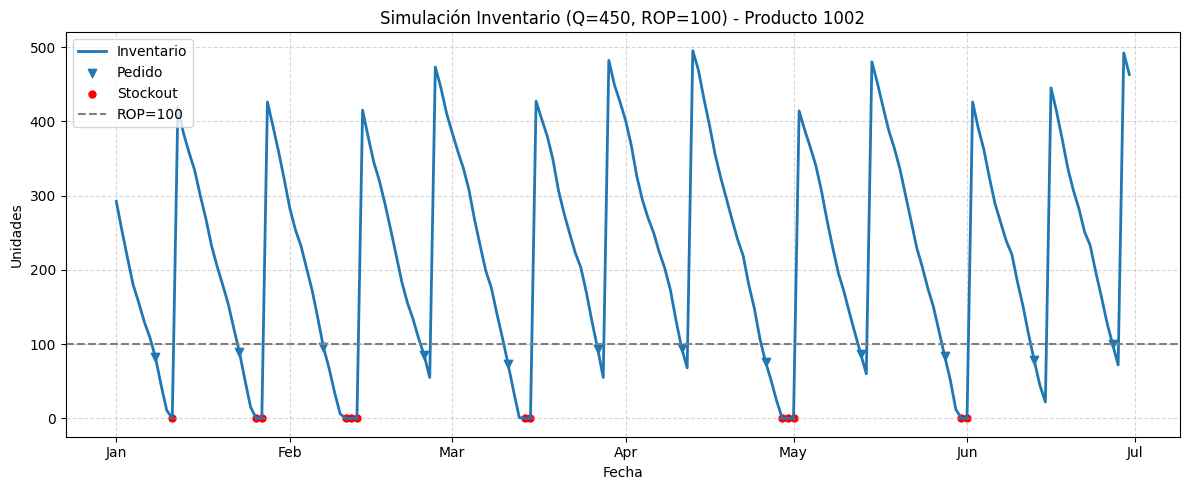

{'Producto': 1002, 'Q': 450, 'ROP': 100, 'h_diario': 0.0072, 'S': 32000.0, 'p': 50.0, 'Nivel_servicio': 0.9427, 'Pedidos': 12, 'Días_con_stockout': 13, 'Costo_Holding': 292.56, 'Costo_Ordering': 384000.0, 'Costo_Stockout': 16000.0, 'Costo_Total': 400292.56}


In [24]:
# Producto a simular
pid = 1002

# Política tentativa
Q_init = 450
ROP_init = 100

# a) Con gráfico
resumen, hist = simulador_inventario(pid, Data_demanda, Data_pedidos, Q_init, ROP_init, graficar=True)
print(resumen)


## Evaluación de políticas mediante cuadrícula de costos

Esta función (`grid_costos`) realiza una **búsqueda exhaustiva** sobre diferentes combinaciones de parámetros \( Q \) y \( ROP \) para un producto dado.  
Su propósito es **comparar el costo total simulado** de cada política de inventario (Q, ROP) y encontrar las combinaciones más eficientes.

###  Proceso
1. Se define un conjunto de valores posibles para \( Q \) (cantidad de pedido) y \( ROP \) (punto de reorden).  
2. Para cada par (Q, ROP), se ejecuta el simulador de inventario.  
3. Se registra el costo total asociado y se devuelve un DataFrame ordenado por menor costo.

In [25]:
def grid_costos(pid, Q_vals, R_vals):
    rows = []
    for Q in Q_vals:
        for R in R_vals:
            res, _ = simulador_inventario(pid, Data_demanda, Data_pedidos, Q, R, graficar=False)
            rows.append(res)
    df = pd.DataFrame(rows)
    return df.sort_values("Costo_Total").reset_index(drop=True)
# Evaluación de políticas mediante cuadrícula de costos
df_grid = grid_costos(1001, Q_vals=range(3000, 24000, 1000), R_vals=range(50, 200, 50))
df_grid.head()


,Producto,Q,ROP,h_diario,S,p,Nivel_servicio,Pedidos,Días_con_stockout,Costo_Holding,Costo_Ordering,Costo_Stockout,Costo_Total
0,1001,8000,50,0.0068,22000.0,60.0,1.0,0,0,2649.73,0.0,0.0,2649.73
1,1001,8000,100,0.0068,22000.0,60.0,1.0,0,0,2712.06,0.0,0.0,2712.06
2,1001,8000,150,0.0068,22000.0,60.0,1.0,0,0,2774.39,0.0,0.0,2774.39
3,1001,9000,50,0.0068,22000.0,60.0,1.0,0,0,3273.02,0.0,0.0,3273.02
4,1001,9000,100,0.0068,22000.0,60.0,1.0,0,0,3335.35,0.0,0.0,3335.35


C:\Users\jlvar\AppData\Local\Temp\ipykernel_33820\714100728.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_fmt = pivot.applymap(lambda v: formato_dinero(v) if pd.notnull(v) else "")


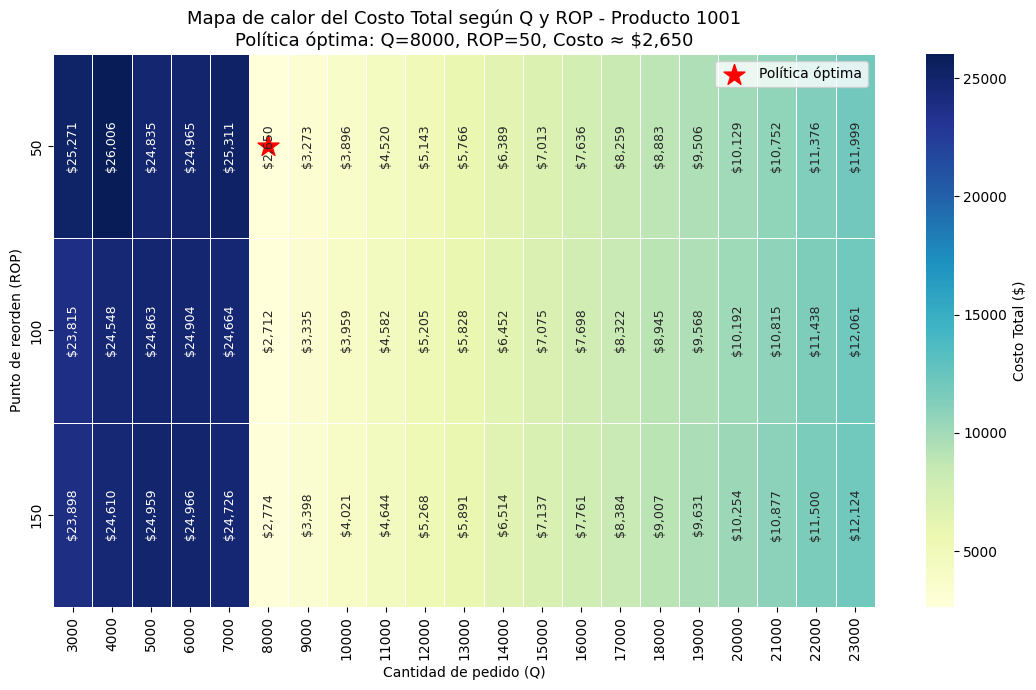

In [26]:
# --- Crear tabla pivote ---
pivot = df_grid.pivot_table(
    index="ROP",
    columns="Q",
    values="Costo_Total",
    aggfunc="mean"
)

# --- Localizar el punto de costo mínimo ---
min_idx = df_grid["Costo_Total"].idxmin()
q_opt = df_grid.loc[min_idx, "Q"]
r_opt = df_grid.loc[min_idx, "ROP"]
min_cost = df_grid.loc[min_idx, "Costo_Total"]

# --- Formatear valores como dinero ---
def formato_dinero(x):
    return f"${x:,.0f}"

pivot_fmt = pivot.applymap(lambda v: formato_dinero(v) if pd.notnull(v) else "")

# --- Crear figura ---
plt.figure(figsize=(11,7))

# --- Heatmap con etiquetas verticales y formato monetario ---
ax = sns.heatmap(
    pivot,
    annot=pivot_fmt,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.4,
    cbar_kws={'label': 'Costo Total ($)'},
    annot_kws={"rotation": 90, "fontsize": 9, "va": "center", "ha": "center"}  # texto vertical
)

# --- Añadir marcador del punto óptimo ---
x_idx = list(pivot.columns).index(q_opt)
y_idx = list(pivot.index).index(r_opt)
plt.scatter(x_idx + 0.5, y_idx + 0.5, color="red", marker="*", s=250, label="Política óptima")

# --- Etiquetas y título ---
plt.title(
    f"Mapa de calor del Costo Total según Q y ROP - Producto 1001\n"
    f"Política óptima: Q={q_opt}, ROP={r_opt}, Costo ≈ {formato_dinero(min_cost)}",
    fontsize=13
)
plt.xlabel("Cantidad de pedido (Q)")
plt.ylabel("Punto de reorden (ROP)")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()


## Función de evaluación de política

La función `evaluar_politica` ejecuta el simulador de inventario para un producto y una combinación específica de parámetros \( Q \) y \( ROP \), devolviendo únicamente el **costo total** asociado.  
Se utiliza como **función objetivo** dentro de los algoritmos de búsqueda y optimización.


In [27]:
def evaluar_politica(pid, Q, R, Data_demanda, Data_pedidos):
    res, _ = simulador_inventario(pid, Data_demanda, Data_pedidos, Q, R, graficar=False)
    return res["Costo_Total"]


# Optimización mediante búsqueda local (Local Search)

La función `local_search_QROP` implementa un **algoritmo de búsqueda local** para encontrar combinaciones de \( Q \) (cantidad de pedido) y \( ROP \) (punto de reorden) que **minimicen el costo total del inventario**.

### ¿Cómo funciona?

1. **Punto inicial:**  
   Parte de una política inicial definida por \( Q_{\text{inicial}} \) y \( R_{\text{inicial}} \).

2. **Vecindad:**  
   En cada iteración, genera un conjunto de políticas vecinas modificando los valores de \( Q \) y \( ROP \) en incrementos o decrementos fijos (`paso_Q`, `paso_R`).

3. **Evaluación:**  
   Calcula el **costo total** para cada vecino mediante `evaluar_politica`, que usa el simulador de inventario.

4. **Selección:**  
   Si se encuentra un vecino con menor costo, el algoritmo se mueve hacia esa solución; de lo contrario, **detiene la búsqueda** (mínimo local alcanzado).

5. **Historial:**  
   Guarda la evolución de los parámetros y sus costos para análisis posterior.

### Parámetros clave
- `paso_Q`, `paso_R`: tamaño de los movimientos en la vecindad (granularidad de búsqueda).  
- `max_iter`: número máximo de iteraciones.  
- `verbose`: muestra la evolución del proceso si es `True`.

### Resultado
Devuelve los valores óptimos encontrados:
- `mejor_Q`, `mejor_R`, `mejor_costo`: configuración con el menor costo total.
- `historia`: lista con el recorrido de la búsqueda (útil para graficar o analizar convergencia).


In [28]:
def local_search_QROP(pid, Data_demanda, Data_pedidos,
                      Q_inicial, R_inicial,
                      paso_Q=500, paso_R=50,
                      max_iter=50, verbose=True):
    """
    Búsqueda local simple para minimizar el costo total de inventario.
    """

    mejor_Q, mejor_R = Q_inicial, R_inicial
    mejor_costo = evaluar_politica(pid, mejor_Q, mejor_R, Data_demanda, Data_pedidos)

    if verbose:
        print(f"Inicio: Q={mejor_Q}, R={mejor_R}, Costo={mejor_costo:,.0f}")

    historia = [(mejor_Q, mejor_R, mejor_costo)]

    for i in range(max_iter):
        # Definir vecindad
        vecinos = [
            (mejor_Q + paso_Q, mejor_R),
            (mejor_Q - paso_Q, mejor_R),
            (mejor_Q, mejor_R + paso_R),
            (mejor_Q, mejor_R - paso_R)
        ]

        # Filtrar negativos o cero
        vecinos = [(Q, R) for Q, R in vecinos if Q > 0 and R > 0]

        # Evaluar vecinos
        costos = []
        for Q, R in vecinos:
            costo = evaluar_politica(pid, Q, R, Data_demanda, Data_pedidos)
            costos.append((Q, R, costo))

        # Seleccionar mejor vecino
        Q_best, R_best, costo_best = min(costos, key=lambda x: x[2])

        if costo_best < mejor_costo:
            mejor_Q, mejor_R, mejor_costo = Q_best, R_best, costo_best
            if verbose:
                print(f"Iter {i+1}: mejora → Q={mejor_Q}, R={mejor_R}, Costo={mejor_costo:,.0f}")
        else:
            if verbose:
                print(f"Iter {i+1}: sin mejora, fin de búsqueda")
            break

        historia.append((mejor_Q, mejor_R, mejor_costo))

    return mejor_Q, mejor_R, mejor_costo, historia


## Ejecución del algoritmo de búsqueda local

Se aplica la función `local_search_QROP` para optimizar los parámetros de inventario \( Q \) y \( ROP \) del producto seleccionado.  
El objetivo es **minimizar el costo total** ajustando ambos valores de forma iterativa hasta alcanzar una solución estable (sin mejoras adicionales).


In [29]:
pid = 1001
Q0, R0 = 10000, 100  # valores iniciales razonables

Q_opt, R_opt, costo_opt, hist = local_search_QROP(
    pid, Data_demanda, Data_pedidos, Q0, R0,
    paso_Q=500, paso_R=25, max_iter=30
)

print(f"\n🔹 Óptimo encontrado: Q={Q_opt}, R={R_opt}, Costo ≈ ${costo_opt:,.0f}")


Inicio: Q=10000, R=100, Costo=3,959
Iter 1: mejora → Q=9500, R=100, Costo=3,647
Iter 2: mejora → Q=9000, R=100, Costo=3,335
Iter 3: mejora → Q=8500, R=100, Costo=3,024
Iter 4: mejora → Q=8000, R=100, Costo=2,712
Iter 5: mejora → Q=8000, R=75, Costo=2,681
Iter 6: mejora → Q=8000, R=50, Costo=2,650
Iter 7: mejora → Q=8000, R=25, Costo=2,619
Iter 8: sin mejora, fin de búsqueda

🔹 Óptimo encontrado: Q=8000, R=25, Costo ≈ $2,619


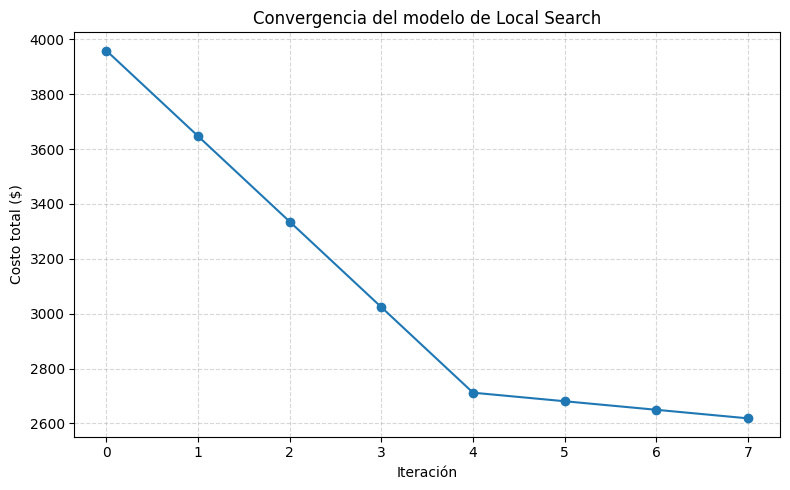

In [30]:
df_hist = pd.DataFrame(hist, columns=["Q","ROP","Costo"])
plt.figure(figsize=(8,5))
plt.plot(df_hist["Costo"], marker="o")
plt.title("Convergencia del modelo de Local Search")
plt.xlabel("Iteración")
plt.ylabel("Costo total ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# Optimización con *Iterated Local Search (ILS)*

Esta sección implementa un enfoque **metaheurístico robusto** para optimizar las políticas de inventario tipo **(Q, ROP)**.  
El objetivo es **minimizar el costo total esperado** del sistema combinando búsqueda local y mecanismos de escape ante mínimos locales.

## Componentes principales

### 1️ `evaluar_promedio`
Ejecuta varias simulaciones con la misma política y devuelve el **costo promedio**, suavizando el ruido aleatorio del simulador (por ejemplo, variaciones en los tiempos de entrega).

### 2️ `local_search`
Realiza una **búsqueda local determinista**:
- Explora una vecindad rectangular alrededor de la política actual.  
- Se mueve hacia el **primer vecino** que reduce el costo (enfoque *greedy*).  
- Se detiene al no encontrar mejoras.

### 3️ `perturbar`
Introduce una **perturbación controlada** en los valores de \( Q \) y \( ROP \) (por defecto ±20%).  
Esta operación permite “sacudir” la solución actual para escapar de óptimos locales.

### 4️ `iterated_local_search`
Integra las funciones anteriores en un ciclo de **optimización iterativa**:
- Comienza con una búsqueda local desde una solución inicial.  
- Aplica perturbaciones y realiza nuevas búsquedas locales desde esos puntos.  
- Usa una **probabilidad controlada de aceptar soluciones peores**, inspirada en el *Simulated Annealing*, para evitar el estancamiento.  
- Registra la evolución de las soluciones y actualiza el mejor resultado global encontrado.

## Parámetros clave
- `iteraciones`: número de ciclos principales del algoritmo.  
- `paso_Q`, `paso_R`: magnitud de los movimientos en la vecindad local.  
- `escala_perturbacion`: porcentaje de cambio aleatorio permitido en cada perturbación.  
- `prob_aceptar_peor_inicial`: probabilidad inicial de aceptar una solución peor (disminuye con las iteraciones).

## Resultado
Devuelve:
- `mejor_Q`, `mejor_R`: parámetros óptimos de política encontrados.  
- `mejor_costo`: costo total asociado a la mejor solución.  
- `historia`: registro completo del proceso de búsqueda y su convergencia.

In [31]:
def evaluar_promedio(pid, Q, R, Data_demanda, Data_pedidos, repeticiones=3):
    """
    Evalúa la política varias veces para suavizar ruido del simulador.
    Retorna el promedio del costo total.
    """
    costos = []
    for _ in range(repeticiones):
        res, _ = simulador_inventario(pid, Data_demanda, Data_pedidos, Q, R, graficar=False)
        costos.append(res["Costo_Total"])
    return np.mean(costos)

def local_search(pid, Data_demanda, Data_pedidos, Q_inicial, R_inicial,
                 paso_Q=500, paso_R=50, max_iter=20):
    """
    Búsqueda local simple con vecindad rectangular.
    """
    Q_act, R_act = Q_inicial, R_inicial
    costo_act = evaluar_promedio(pid, Q_act, R_act, Data_demanda, Data_pedidos)
    mejora = True
    while mejora:
        mejora = False
        vecinos = [
            (Q_act + paso_Q, R_act), (Q_act - paso_Q, R_act),
            (Q_act, R_act + paso_R), (Q_act, R_act - paso_R)
        ]
        vecinos = [(Q, R) for Q, R in vecinos if Q > 0 and R > 0]
        for Qv, Rv in vecinos:
            costo_v = evaluar_promedio(pid, Qv, Rv, Data_demanda, Data_pedidos)
            if costo_v < costo_act:
                Q_act, R_act, costo_act = Qv, Rv, costo_v
                mejora = True
                break  # moverse al mejor vecino encontrado (greedy)
    return Q_act, R_act, costo_act

def perturbar(Q, R, escala_Q=0.2, escala_R=0.2):
    """
    Genera una perturbación proporcional (±20% por defecto)
    """
    Qn = max(100, int(Q + np.random.uniform(-escala_Q, escala_Q) * Q))
    Rn = max(10, int(R + np.random.uniform(-escala_R, escala_R) * R))
    return Qn, Rn

def iterated_local_search(pid, Data_demanda, Data_pedidos,
                          Q_inicial, R_inicial,
                          iteraciones=20,
                          paso_Q=500, paso_R=50,
                          escala_perturbacion=0.2,
                          prob_aceptar_peor_inicial=0.1,
                          repeticiones_eval=2,
                          verbose=True):
    """
    Iterated Local Search (ILS) robusta con mejor_global fijo
    y enfriamiento exponencial de aceptación.
    """
    # --- Búsqueda local inicial ---
    Q_act, R_act, costo_act = local_search(pid, Data_demanda, Data_pedidos, Q_inicial, R_inicial, paso_Q, paso_R)
    mejor_Q, mejor_R, mejor_costo = Q_act, R_act, costo_act

    historia = [(0, Q_act, R_act, costo_act)]

    if verbose:
        print(f"Inicio: Q={Q_act}, R={R_act}, Costo={costo_act:,.0f}")

    # --- Bucle principal ---
    for i in range(1, iteraciones + 1):
        # Factor de enfriamiento (simulated annealing light)
        temp = 1 - i / iteraciones
        prob_aceptar_peor = prob_aceptar_peor_inicial * temp

        # Perturbar solución actual
        Qp, Rp = perturbar(Q_act, R_act, escala_perturbacion, escala_perturbacion)

        # Búsqueda local desde la perturbación
        Q_loc, R_loc, costo_loc = local_search(pid, Data_demanda, Data_pedidos, Qp, Rp, paso_Q, paso_R)

        # Decidir si se acepta
        mejora = costo_loc < costo_act
        delta = costo_loc - costo_act
        aceptar = mejora or (np.random.rand() < np.exp(-max(delta,0)/(mejor_costo*0.05)))  # enfriamiento suave

        if aceptar:
            Q_act, R_act, costo_act = Q_loc, R_loc, costo_loc
            if costo_act < mejor_costo:
                mejor_Q, mejor_R, mejor_costo = Q_act, R_act, costo_act
                if verbose:
                    print(f"Iter {i}: nuevo mejor global → Q={mejor_Q}, R={mejor_R}, Costo={mejor_costo:,.0f}")
            elif verbose:
                print(f"Iter {i}: aceptado peor (escape), costo={costo_act:,.0f}")
        else:
            if verbose:
                print(f"Iter {i}: rechazada solución peor ({costo_loc:,.0f})")

        historia.append((i, Q_act, R_act, costo_act))

    return mejor_Q, mejor_R, mejor_costo, historia




In [34]:
pid = 1001
Q0, R0 = 5000, 100

Q_opt, R_opt, costo_opt, hist = iterated_local_search(
    pid, Data_demanda, Data_pedidos,
    Q_inicial=Q0, R_inicial=R0,
    iteraciones=50,
    paso_Q=500, paso_R=25,
    escala_perturbacion=0.25,
    prob_aceptar_peor_inicial=0.2,
    repeticiones_eval=2,
    verbose=True
)

print(f"\n✅ Óptimo final encontrado:")
print(f"   Q = {Q_opt}")
print(f"   ROP = {R_opt}")
print(f"   Costo total ≈ ${costo_opt:,.0f}")


Inicio: Q=8000, R=25, Costo=2,619
Iter 1: nuevo mejor global → Q=7943, R=20, Costo=2,576
Iter 2: nuevo mejor global → Q=7698, R=17, Costo=2,420
Iter 3: rechazada solución peor (24,894)
Iter 4: aceptado peor (escape), costo=2,494
Iter 5: rechazada solución peor (23,775)
Iter 6: rechazada solución peor (24,911)
Iter 7: rechazada solución peor (24,871)
Iter 8: rechazada solución peor (2,610)
Iter 9: rechazada solución peor (2,610)
Iter 10: aceptado peor (escape), costo=2,552
Iter 11: rechazada solución peor (2,595)
Iter 12: aceptado peor (escape), costo=2,615
Iter 13: rechazada solución peor (24,864)
Iter 14: aceptado peor (escape), costo=2,444
Iter 15: nuevo mejor global → Q=7673, R=16, Costo=2,403
Iter 16: aceptado peor (escape), costo=2,523
Iter 17: aceptado peor (escape), costo=2,442
Iter 18: nuevo mejor global → Q=7667, R=18, Costo=2,402
Iter 19: rechazada solución peor (2,572)
Iter 20: rechazada solución peor (25,516)
Iter 21: rechazada solución peor (2,540)
Iter 22: rechazada soluc

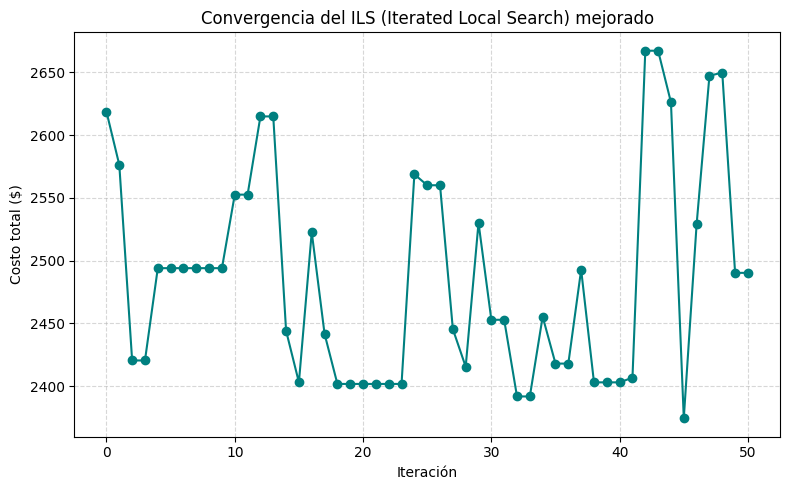

In [35]:
df_hist = pd.DataFrame(hist, columns=["Iteración","Q","ROP","Costo"])
plt.figure(figsize=(8,5))
plt.plot(df_hist["Iteración"], df_hist["Costo"], marker="o", color="teal")
plt.title("Convergencia del ILS (Iterated Local Search) mejorado")
plt.xlabel("Iteración")
plt.ylabel("Costo total ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [37]:
#!pip install scikit-opt
from sko.PSO import PSO

In [38]:
def objective_function(x):
    """
    Función objetivo para PSO.
    x: vector [Q, ROP]
    """
    Q, R = int(x[0]), int(x[1])

    if Q <= 0 or R <= 0:
        return 1e9  # penalización por valores inválidos

    try:
        res, _ = simulador_inventario(1001, Data_demanda, Data_pedidos, Q, R, graficar=False)
        cost = res["Costo_Total"]
    except Exception:
        cost = 1e9

    return cost


In [39]:
# Configurar el optimizador de partículas
pso = PSO(
    func=objective_function,
    n_dim=2,                # número de variables (Q y ROP)
    pop=30,                 # tamaño de la población
    max_iter=50,            # número de iteraciones
    lb=[100, 10],           # límites inferiores [Q, ROP]
    ub=[10000, 500],        # límites superiores [Q, ROP]
    w=0.8,                  # inercia (balance exploración/explotación)
    c1=1.5, c2=1.5          # factores cognitivo y social
)

# Entrenamiento
pso.run()


(array([7638.62614936,   10.        ]), array([2374.24]))

In [40]:
best_Q, best_ROP = pso.gbest_x
best_cost = pso.gbest_y

print(f"🔹 Mejor solución encontrada:")
print(f"   Q   = {int(best_Q)}")
print(f"   ROP = {int(best_ROP)}")
print(f"   Costo total ≈ ${best_cost[0]:,.0f}")


🔹 Mejor solución encontrada:
   Q   = 7638
   ROP = 10
   Costo total ≈ $2,374


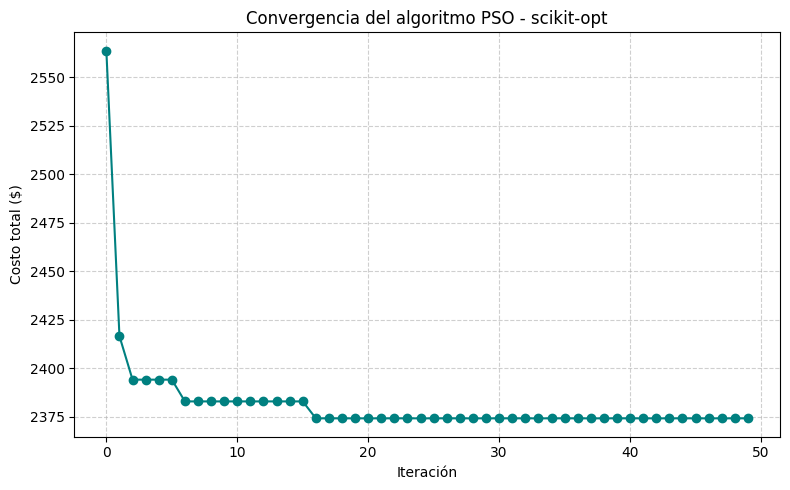

In [41]:
plt.figure(figsize=(8,5))
plt.plot(pso.gbest_y_hist, marker="o", color="teal")
plt.title("Convergencia del algoritmo PSO - scikit-opt")
plt.xlabel("Iteración")
plt.ylabel("Costo total ($)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


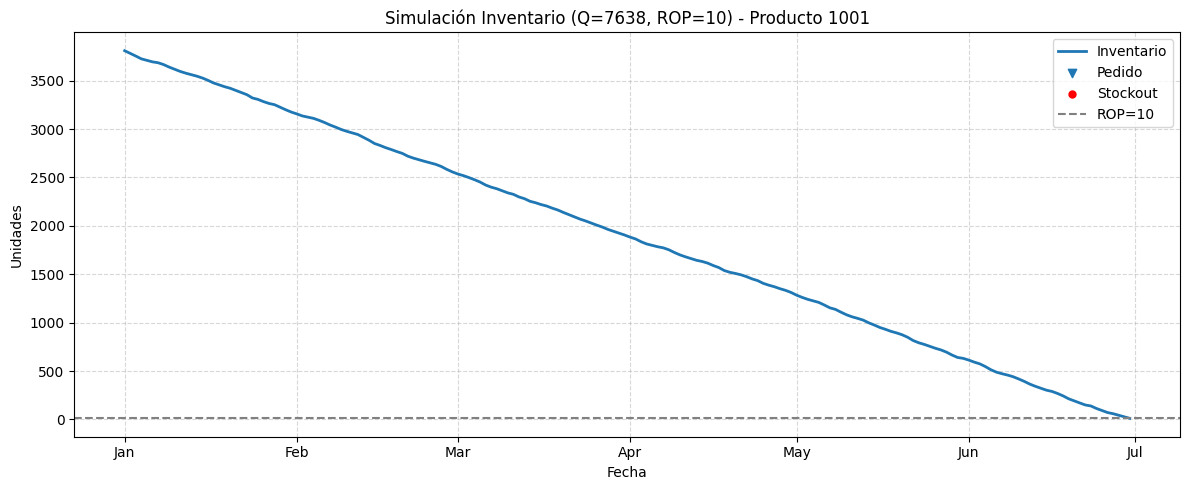

{'Producto': 1001, 'Q': 7638, 'ROP': 10, 'h_diario': 0.0068, 'S': 22000.0, 'p': 60.0, 'Nivel_servicio': 1.0, 'Pedidos': 0, 'Días_con_stockout': 0, 'Costo_Holding': 2374.24, 'Costo_Ordering': 0.0, 'Costo_Stockout': 0.0, 'Costo_Total': 2374.24}


In [42]:
resumen, hist = simulador_inventario(1001, Data_demanda, Data_pedidos,
                                     int(best_Q), int(best_ROP),
                                     graficar=True)
print(resumen)
